In [1]:
import mplhep as hep
hep.style.use("LHCb2")
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import os
from os.path import join

In [2]:
def plot_histogram(df, x_col, weight_col=None, bins=10):
    """
    Plots a histogram of x_col from df, optionally weighted by weight_col.
    
    :param df: pandas DataFrame containing the data
    :param x_col: Column name for histogram
    :param weight_col: Optional column name for weight
    :param bins: Number of bins for the histogram
    """
    plt.figure(figsize=(8, 6))
    plt.hist(df[x_col], bins=bins, weights=df[weight_col], alpha=0.9, edgecolor='blue', label=f'sWeighted', histtype="step", density=True)
    plt.hist(df[x_col], bins=bins, alpha=0.9, edgecolor='gray', label=f'unWeighted', histtype="step", density=True)
    
    plt.xlabel(x_col)
    plt.ylabel('Counts')
    plt.legend()
    plt.show()
    plt.close()


In [3]:
input_dir = "/work/celani/flavour_tagging/ntuples/withUT_MC_2024/4_tagged/Bu2JpsiK/OSKaon/notSamePV_noOSP/union_PROBNN"
with open("block12_list.txt", "r") as f:
    files_s24c2 = f.readlines()
files_s24c2 = [os.path.basename(line).replace("\n", "") for line in files_s24c2]
input_files = [join(input_dir, line) for line in files_s24c2]

In [4]:
vars = ['FillNumber']
df_data = pd.DataFrame()
for file in input_files:
    with uproot.open(file) as f:
        _df = f['DecayTree'].arrays(library="pd")
    df_data = pd.concat([df_data, _df])

In [13]:
print(df_data.columns)

Index(['index', 'entry', 'RUNNUMBER', 'EVENTNUMBER', 'OSKaon_TagDec',
       'OSKaon_Eta', 'B_ID', 'B_Run2_SSPion_Dec', 'B_Run2_SSPion_Omega',
       'B_Run2_SSPion_MVA', 'B_Run2_SSKaon_Dec', 'B_Run2_SSKaon_Omega',
       'B_Run2_SSKaon_MVA', 'B_Run2_SSProton_Dec', 'B_Run2_SSProton_Omega',
       'B_Run2_SSProton_MVA', 'B_Run2_OSKaon_Dec', 'B_Run2_OSKaon_Omega',
       'B_Run2_OSKaon_MVA', 'B_Run2_OSElectron_Dec', 'B_Run2_OSElectron_Omega',
       'B_Run2_OSElectron_MVA', 'B_Run2_OSMuon_Dec', 'B_Run2_OSMuon_Omega',
       'B_Run2_OSMuon_MVA', 'FillNumber', 'B_DTF_PV_Jpsi_MASS',
       'B_DTF_PV_MASS'],
      dtype='object')


In [5]:
df_block1 = df_data.query("(FillNumber < 10056 and FillNumber > 9982) and (B_DTF_PV_Jpsi_MASS > 5200 and B_DTF_PV_Jpsi_MASS < 5400)")


In [6]:
sw_file = "/work/celani/flavour_tagging/data_calib_output/Bu2JpsiK/data_fit/sweights.root"
with uproot.open(sw_file) as _sw:
    df_sw = _sw['DecayTree'].arrays(library="pd")
assert(len(df_block1) == len(df_sw))

In [7]:
df_block1["signal_weights"] = df_sw['signal_weights']

/tmp/ipykernel_2590359/1484253654.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_block1["signal_weights"] = df_sw['signal_weights']


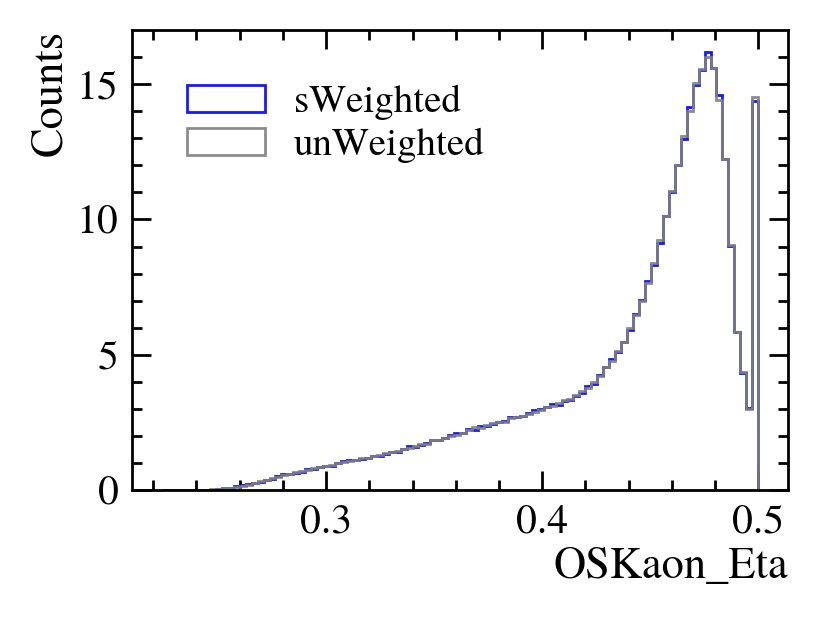

In [9]:
plot_histogram(df_block1, "OSKaon_Eta", weight_col="signal_weights", bins=100)


In [10]:
df_block1[:10]

,index,entry,RUNNUMBER,EVENTNUMBER,OSKaon_TagDec,OSKaon_Eta,B_ID,B_Run2_SSPion_Dec,B_Run2_SSPion_Omega,B_Run2_SSPion_MVA,...,B_Run2_OSElectron_Dec,B_Run2_OSElectron_Omega,B_Run2_OSElectron_MVA,B_Run2_OSMuon_Dec,B_Run2_OSMuon_Omega,B_Run2_OSMuon_MVA,FillNumber,B_DTF_PV_Jpsi_MASS,B_DTF_PV_MASS,signal_weights
1,1,1,304543,53967621610,0.0,0.500000,521,0,0.500000,0.000000,...,0,0.5,0.0,0,0.5,0.0,10052,5270.622251,5297.149726,-0.028334
3,3,3,304543,72104735940,1.0,0.373507,-521,1,0.464294,-0.115320,...,0,0.5,0.0,0,0.5,0.0,10052,5306.299756,5222.409744,-0.309288
4,4,4,304543,78638009252,-1.0,0.489673,-521,0,0.500000,0.000000,...,0,0.5,0.0,0,0.5,0.0,10052,5343.349862,5241.593318,0.871172
7,7,7,304543,32388225825,1.0,0.455075,521,-1,0.464442,-0.116932,...,0,0.5,0.0,0,0.5,0.0,10052,5228.452403,5259.854420,0.887412
8,8,8,304543,80079017791,1.0,0.440426,-521,0,0.500000,0.000000,...,0,0.5,0.0,0,0.5,0.0,10052,5292.174278,5390.090714,1.210255
9,9,9,304543,95092954904,-1.0,0.481388,-521,0,0.500000,0.000000,...,0,0.5,0.0,0,0.5,0.0,10052,5321.891397,5302.558743,0.903124
10,10,10,304543,74992350043,1.0,0.360903,-521,0,0.500000,0.000000,...,0,0.5,0.0,0,0.5,0.0,10052,5240.676038,5276.482871,-0.266978
11,11,11,304543,75011969515,-1.0,0.462963,-521,1,0.470819,-0.191733,...,0,0.5,0.0,0,0.5,0.0,10052,5291.929644,5284.319139,1.262013
12,12,12,304543,44707013286,0.0,0.500000,-521,0,0.500000,0.000000,...,0,0.5,0.0,0,0.5,0.0,10052,5284.851439,5277.604327,-0.309929
13,13,13,304543,89067118160,1.0,0.359580,521,0,0.500000,0.000000,...,0,0.5,0.0,0,0.5,0.0,10052,5291.688755,5280.934686,-0.156025
